# Event Direction Label Audit

This notebook audits the existing `is_charging_event` and `is_flight_event` labels by inferring event direction directly from SOC movement.

Method:
- use aux parquet rows only
- compute pack-level `delta_soc = soc_end - soc_start` from robust start/end medians
- classify each pack as `charge`, `discharge`, or `flat`
- collapse the two pack directions into one event-level inferred direction
- compare that inferred direction against the current event labels


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.dataset as ds

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "ml_workspace").exists() and (candidate / ".gitignore").exists():
            return candidate
    raise RuntimeError("Could not locate repo root containing ml_workspace")

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

TIMESERIES_PATH = REPO_ROOT / "data" / "event_timeseries.parquet"
SOC_THRESHOLD_PCT = 2.0
START_END_WINDOW_ROWS = 20
MIN_ROWS_PER_PACK_EVENT = 5

plt.style.use("seaborn-v0_8-whitegrid")


## 1. Load aux rows

In [2]:
dataset = ds.dataset(str(TIMESERIES_PATH), format="parquet")
columns = [
    "plane_id",
    "flight_id",
    "event_datetime",
    "is_charging_event",
    "is_flight_event",
    "source_csv_kind",
    "source_pack_id",
    "time_ms",
    " bat 1 soc",
    " bat 2 soc",
]
table = dataset.to_table(
    columns=columns,
    filter=(ds.field("source_csv_kind") == "aux") & ((ds.field("source_pack_id") == 1) | (ds.field("source_pack_id") == 2)),
)
raw_df = table.to_pandas()
raw_df["event_datetime"] = pd.to_datetime(raw_df["event_datetime"], errors="coerce")
raw_df.head()


,plane_id,flight_id,event_datetime,is_charging_event,is_flight_event,source_csv_kind,source_pack_id,time_ms,bat 1 soc,bat 2 soc
0,166,4575,2023-05-16 11:00:00,1,0,aux,1,2674.612,77.0,NaN
1,166,4575,2023-05-16 11:00:00,1,0,aux,1,2874.889,77.0,NaN
2,166,4575,2023-05-16 11:00:00,1,0,aux,1,3076.047,77.0,NaN
3,166,4575,2023-05-16 11:00:00,1,0,aux,1,3274.571,77.0,NaN
4,166,4575,2023-05-16 11:00:00,1,0,aux,1,3474.980,77.0,NaN


## 2. Build pack-level SOC direction summaries

In [3]:
pack_rows = []
for battery_id in [1, 2]:
    soc_col = f" bat {battery_id} soc"
    sub = raw_df.loc[raw_df["source_pack_id"] == battery_id].copy()
    sub["soc_pct"] = pd.to_numeric(sub[soc_col], errors="coerce")
    sub["time_ms"] = pd.to_numeric(sub["time_ms"], errors="coerce")
    sub = sub.dropna(subset=["soc_pct", "time_ms", "event_datetime"])
    
    for keys, group in sub.groupby(["plane_id", "flight_id", "event_datetime", "is_charging_event", "is_flight_event"], sort=False):
        g = group.sort_values("time_ms").drop_duplicates("time_ms")
        if len(g) < MIN_ROWS_PER_PACK_EVENT:
            continue
        win = min(START_END_WINDOW_ROWS, len(g))
        soc_start = g["soc_pct"].head(win).median()
        soc_end = g["soc_pct"].tail(win).median()
        pack_rows.append({
            "plane_id": str(keys[0]),
            "flight_id": int(keys[1]),
            "event_datetime": keys[2],
            "is_charging_event": int(keys[3]),
            "is_flight_event": int(keys[4]),
            "battery_id": battery_id,
            "soc_start": float(soc_start),
            "soc_end": float(soc_end),
            "delta_soc": float(soc_end - soc_start),
            "n_rows": int(len(g)),
        })

pack_event_df = pd.DataFrame(pack_rows)
pack_event_df["pack_direction"] = np.where(
    pack_event_df["delta_soc"] >= SOC_THRESHOLD_PCT,
    "charge",
    np.where(pack_event_df["delta_soc"] <= -SOC_THRESHOLD_PCT, "discharge", "flat"),
)
pack_event_df.head()


,plane_id,flight_id,event_datetime,is_charging_event,is_flight_event,battery_id,soc_start,soc_end,delta_soc,n_rows,pack_direction
0,166,4575,2023-05-16 11:00:00,1,0,1,77.0,100.0,23.0,15745,charge
1,166,4576,2023-05-16 12:44:00,0,0,1,100.0,29.0,-71.0,9638,discharge
2,166,4577,2023-05-16 13:00:00,1,0,1,29.0,100.0,71.0,18774,charge
3,166,4578,2023-05-16 14:35:00,0,0,1,100.0,29.0,-71.0,11409,discharge
4,166,4579,2023-05-16 15:00:00,1,0,1,29.0,100.0,71.0,20922,charge


## 3. Collapse to event-level inferred direction

In [4]:
event_rows = []
for keys, group in pack_event_df.groupby(["plane_id", "flight_id", "event_datetime", "is_charging_event", "is_flight_event"], sort=False):
    directions = group["pack_direction"].tolist()
    if all(direction == "charge" for direction in directions):
        inferred = "charge"
    elif all(direction == "discharge" for direction in directions):
        inferred = "discharge"
    elif any(direction == "charge" for direction in directions) and any(direction == "discharge" for direction in directions):
        inferred = "mixed"
    elif any(direction == "charge" for direction in directions):
        inferred = "charge_weak"
    elif any(direction == "discharge" for direction in directions):
        inferred = "discharge_weak"
    else:
        inferred = "flat"

    if int(keys[3]) == 1:
        label_direction = "charge"
    elif int(keys[4]) == 1:
        label_direction = "discharge"
    else:
        label_direction = "other"

    event_rows.append({
        "plane_id": str(keys[0]),
        "flight_id": int(keys[1]),
        "event_datetime": keys[2],
        "is_charging_event": int(keys[3]),
        "is_flight_event": int(keys[4]),
        "label_direction": label_direction,
        "inferred_direction": inferred,
        "pack_directions": "/".join(f"{int(b)}:{d}" for b, d in zip(group["battery_id"], group["pack_direction"])),
        "delta_soc_mean": float(group["delta_soc"].mean()),
        "delta_soc_min": float(group["delta_soc"].min()),
        "delta_soc_max": float(group["delta_soc"].max()),
    })

event_df = pd.DataFrame(event_rows).sort_values(["plane_id", "event_datetime", "flight_id"]).reset_index(drop=True)
event_df.head()


,plane_id,flight_id,event_datetime,is_charging_event,is_flight_event,label_direction,inferred_direction,pack_directions,delta_soc_mean,delta_soc_min,delta_soc_max
0,166,4575,2023-05-16 11:00:00,1,0,charge,charge,1:charge/2:charge,23.0,23.0,23.0
1,166,4576,2023-05-16 12:44:00,0,0,other,discharge,1:discharge/2:discharge,-71.0,-71.0,-71.0
2,166,4577,2023-05-16 13:00:00,1,0,charge,charge,1:charge/2:charge,71.0,71.0,71.0
3,166,4578,2023-05-16 14:35:00,0,0,other,discharge,1:discharge/2:discharge,-70.5,-71.0,-70.0
4,166,4579,2023-05-16 15:00:00,1,0,charge,charge,1:charge/2:charge,70.5,70.0,71.0


## 4. Count probable mislabels

In [5]:
charge_ok = {"charge", "charge_weak"}
discharge_ok = {"discharge", "discharge_weak"}

charge_mismatch = event_df[(event_df["label_direction"] == "charge") & (~event_df["inferred_direction"].isin(charge_ok))].copy()
flight_mismatch = event_df[(event_df["label_direction"] == "discharge") & (~event_df["inferred_direction"].isin(discharge_ok))].copy()

summary_rows = []
for plane_id, group in event_df.groupby("plane_id", sort=True):
    charge_events = group[group["label_direction"] == "charge"]
    flight_events = group[group["label_direction"] == "discharge"]
    plane_charge_mismatch = charge_mismatch[charge_mismatch["plane_id"] == plane_id]
    plane_flight_mismatch = flight_mismatch[flight_mismatch["plane_id"] == plane_id]
    summary_rows.append({
        "plane_id": plane_id,
        "total_events": int(len(group)),
        "charge_events": int(len(charge_events)),
        "flight_events": int(len(flight_events)),
        "charge_mismatches": int(len(plane_charge_mismatch)),
        "flight_mismatches": int(len(plane_flight_mismatch)),
        "charge_mismatch_rate_pct": round(100.0 * len(plane_charge_mismatch) / max(len(charge_events), 1), 2),
        "flight_mismatch_rate_pct": round(100.0 * len(plane_flight_mismatch) / max(len(flight_events), 1), 2),
    })

summary_df = pd.DataFrame(summary_rows)
print(f"SOC threshold: {SOC_THRESHOLD_PCT:.1f} pct points")
print(f"Total charge mismatches: {len(charge_mismatch)}")
print(f"Total flight mismatches: {len(flight_mismatch)}")
summary_df


SOC threshold: 2.0 pct points
Total charge mismatches: 14
Total flight mismatches: 12


,plane_id,total_events,charge_events,flight_events,charge_mismatches,flight_mismatches,charge_mismatch_rate_pct,flight_mismatch_rate_pct
0,166,553,303,189,12,10,3.96,5.29
1,192,49,29,20,2,2,6.90,10.00


## 5. Visual checks

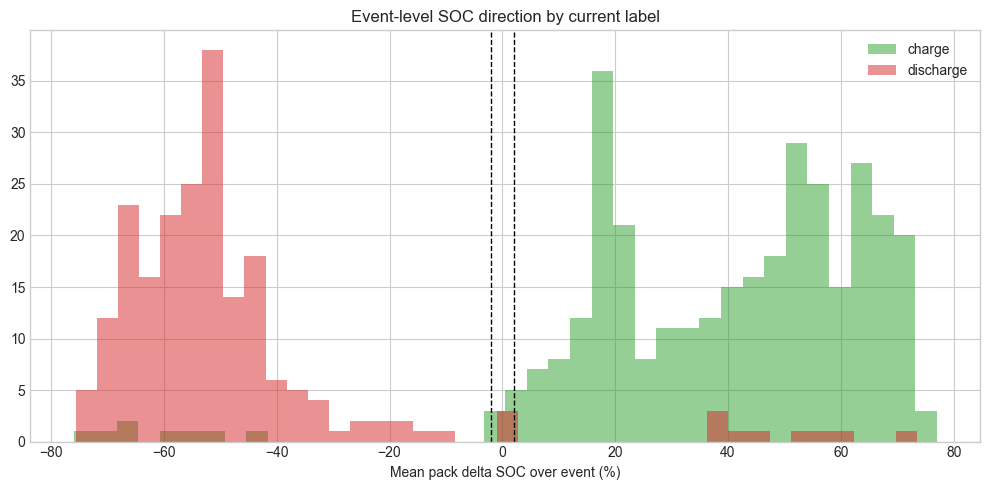

In [6]:
plot_df = event_df[event_df["label_direction"].isin(["charge", "discharge"])].copy()
fig, ax = plt.subplots(figsize=(10, 5))
for label_direction, color in [("charge", "#2ca02c"), ("discharge", "#d62728")]:
    sub = plot_df[plot_df["label_direction"] == label_direction]
    ax.hist(sub["delta_soc_mean"], bins=40, alpha=0.5, label=label_direction, color=color)
ax.axvline(SOC_THRESHOLD_PCT, color="black", linestyle="--", linewidth=1)
ax.axvline(-SOC_THRESHOLD_PCT, color="black", linestyle="--", linewidth=1)
ax.set_title("Event-level SOC direction by current label")
ax.set_xlabel("Mean pack delta SOC over event (%)")
ax.legend()
fig.tight_layout()


In [7]:
confusion = pd.crosstab(event_df["label_direction"], event_df["inferred_direction"], dropna=False)
confusion


inferred_direction,charge,discharge,discharge_weak,flat
label_direction,,,,
charge,318,8,0,6
discharge,9,197,0,3
other,2,54,1,4


## 6. Inspect mismatched events

In [8]:
charge_mismatch.sort_values(["plane_id", "delta_soc_mean"]).head(20)


,plane_id,flight_id,event_datetime,is_charging_event,is_flight_event,label_direction,inferred_direction,pack_directions,delta_soc_mean,delta_soc_min,delta_soc_max
253,166,5779,2024-04-07 16:24:00,1,0,charge,discharge,1:discharge/2:discharge,-76.0,-76.0,-76.0
167,166,5195,2023-10-23 20:40:00,1,0,charge,discharge,1:discharge/2:discharge,-71.0,-72.0,-70.0
38,166,4714,2023-07-05 09:49:00,1,1,charge,discharge,1:discharge/2:discharge,-67.5,-68.0,-67.0
40,166,4759,2023-07-11 09:56:00,1,1,charge,discharge,1:discharge/2:discharge,-60.5,-61.0,-60.0
552,166,12722,2025-12-02 17:35:00,1,0,charge,discharge,1:discharge/2:discharge,-53.5,-56.0,-51.0
149,166,5024,2023-10-17 16:40:00,1,0,charge,discharge,1:discharge/2:discharge,-52.0,-52.0,-52.0
164,166,5193,2023-10-23 16:27:00,1,0,charge,discharge,1:discharge/2:discharge,-44.5,-45.0,-44.0
19,166,4595,2023-05-17 22:00:00,1,0,charge,flat,1:flat/2:flat,0.0,0.0,0.0
508,166,6386,2024-06-11 12:31:00,1,0,charge,flat,1:flat/2:flat,0.0,0.0,0.0
23,166,4614,2023-05-31 15:00:00,1,0,charge,flat,1:flat/2:flat,1.0,1.0,1.0


In [9]:
flight_mismatch.sort_values(["plane_id", "delta_soc_mean"], ascending=[True, False]).head(20)


,plane_id,flight_id,event_datetime,is_charging_event,is_flight_event,label_direction,inferred_direction,pack_directions,delta_soc_mean,delta_soc_min,delta_soc_max
252,166,5778,2024-04-07 14:55:00,0,1,discharge,charge,1:charge/2:charge,73.5,73.0,74.0
148,166,5023,2023-10-17 14:30:00,0,1,discharge,charge,1:charge/2:charge,60.5,60.0,61.0
150,166,5025,2023-10-17 16:40:00,0,1,discharge,charge,1:charge/2:charge,55.0,55.0,55.0
166,166,5194,2023-10-23 20:00:00,0,1,discharge,charge,1:charge/2:charge,45.5,45.0,46.0
538,166,10944,2025-06-06 17:55:00,0,1,discharge,charge,1:charge/2:charge,40.5,40.0,41.0
507,166,6385,2024-06-11 12:30:00,0,1,discharge,charge,1:charge/2:charge,38.5,38.0,39.0
162,166,5190,2023-10-23 16:00:00,0,1,discharge,charge,1:charge/2:charge,37.5,37.0,38.0
163,166,5192,2023-10-23 16:00:00,0,1,discharge,charge,1:charge/2:charge,37.5,37.0,38.0
505,166,6383,2024-06-11 11:00:00,0,1,discharge,flat,1:flat/2:flat,0.0,0.0,0.0
185,166,5109,2023-10-31 13:22:00,0,1,discharge,flat,1:flat/2:flat,-0.5,-1.0,0.0


## 7. Events carrying both charge and flight flags

These are worth checking separately because they can distort any simple label audit.

In [10]:
both_flags = event_df[(event_df["is_charging_event"] == 1) & (event_df["is_flight_event"] == 1)].copy()
print(f"Events with both flags set: {len(both_flags)}")
both_flags.head(20)


Events with both flags set: 5


,plane_id,flight_id,event_datetime,is_charging_event,is_flight_event,label_direction,inferred_direction,pack_directions,delta_soc_mean,delta_soc_min,delta_soc_max
38,166,4714,2023-07-05 09:49:00,1,1,charge,discharge,1:discharge/2:discharge,-67.5,-68.0,-67.0
40,166,4759,2023-07-11 09:56:00,1,1,charge,discharge,1:discharge/2:discharge,-60.5,-61.0,-60.0
46,166,4770,2023-07-22 06:00:00,1,1,charge,charge,1:charge/2:charge,70.5,70.0,71.0
197,166,5108,2023-11-06 16:00:00,1,1,charge,charge,1:charge/2:charge,58.5,58.0,59.0
375,166,6048,2024-05-16 14:35:00,1,1,charge,charge,1:charge/2:charge,43.5,43.0,44.0
